In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder


In [30]:
# part1

user_data = pd.read_csv('ecommerce_user_data.csv')
product_details = pd.read_csv('product_details.csv')

display(user_data.head(10))
display(product_details.head(10))

,UserID,ProductID,Rating,Timestamp,Category
0,U000,P0009,5,2024-09-08,Books
1,U000,P0020,1,2024-09-02,Home
2,U000,P0012,4,2024-10-18,Books
3,U000,P0013,1,2024-09-18,Clothing
4,U000,P0070,4,2024-09-16,Toys
5,U000,P0014,1,2024-09-15,Home
6,U000,P0048,5,2024-09-09,Toys
7,U000,P0079,4,2024-10-18,Electronics
8,U000,P0042,3,2024-09-07,Toys
9,U000,P0050,1,2024-10-14,Clothing


,ProductID,ProductName,Category
0,P0000,Toys Item 0,Clothing
1,P0001,Clothing Item 1,Electronics
2,P0002,Books Item 2,Electronics
3,P0003,Clothing Item 3,Electronics
4,P0004,Clothing Item 4,Electronics
5,P0005,Home Item 5,Toys
6,P0006,Books Item 6,Books
7,P0007,Books Item 7,Books
8,P0008,Books Item 8,Electronics
9,P0009,Clothing Item 9,Books


In [31]:
print(f"\nMissing values:\n{user_data.isnull().sum()}")
print(f"\nDuplicates (UserID, ProductID): {user_data.duplicated(subset=['UserID', 'ProductID']).sum()}")
# no missing values and no duplicates in user_data


Missing values:
UserID       0
ProductID    0
Rating       0
Timestamp    0
Category     0
dtype: int64

Duplicates (UserID, ProductID): 0


In [32]:
user_item_matrix = user_data.pivot_table(index='UserID', columns='ProductID', values='Rating')
user_item_matrix_filled = user_item_matrix.fillna(0)

sparsity = 1 - (user_item_matrix_filled != 0).sum().sum() / user_item_matrix_filled.size
print(f"Matrix: {user_item_matrix_filled.shape[0]} users × {user_item_matrix_filled.shape[1]} products")
print(f"Sparsity: {sparsity:.2%}")

user_item_matrix_filled.head()
# sparisty is 85.52% meaning  each users has rated only 15 out of 100 products on average.
# this will make it difficult for collaborative filtering to find similar users or products, as there is limited data to compare.

Matrix: 50 users × 100 products
Sparsity: 85.52%


ProductID,P0000,P0001,P0002,P0003,P0004,P0005,P0006,P0007,P0008,P0009,...,P0090,P0091,P0092,P0093,P0094,P0095,P0096,P0097,P0098,P0099
UserID,,,,,,,,,,,,,,,,,,,,,
U000,0.0,0.0,0.0,3.0,0.0,5.0,0.0,3.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
U001,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,5.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0
U002,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
U003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
U004,0.0,3.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,...,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,4.0,3.0


In [33]:
user_category_agg = user_data.groupby(['UserID', 'Category']).agg({'Rating': ['count', 'mean']}).reset_index()
user_category_agg.columns = ['UserID', 'Category', 'TotalInteractions', 'AverageRating']
user_category_agg.round(2).head(15)


,UserID,Category,TotalInteractions,AverageRating
0,U000,Books,6,3.67
1,U000,Clothing,3,1.67
2,U000,Electronics,3,3.67
3,U000,Home,2,1.00
4,U000,Toys,6,3.50
5,U001,Beauty,1,4.00
6,U001,Books,4,2.50
7,U001,Clothing,4,2.50
8,U001,Electronics,2,4.00
9,U001,Home,1,2.00


In [ ]:
#part 2
# Compute similarity between every pair of users using the user-item matrix
user_similarity = cosine_similarity(user_item_matrix_filled)

user_similarity_df = pd.DataFrame(user_similarity, 
                                   index=user_item_matrix_filled.index, 
                                   columns=user_item_matrix_filled.index)
user_similarity_df.head()
# scores range from 0 to 1, where 1 means identical preferences and 0 means no similarity.
# users who rated the same products similarly will have higher similarity scores.

UserID,U000,U001,U002,U003,U004,U005,U006,U007,U008,U009,...,U040,U041,U042,U043,U044,U045,U046,U047,U048,U049
UserID,,,,,,,,,,,,,,,,,,,,,
U000,1.000000,0.063071,0.195522,0.023466,0.065412,0.161251,0.160096,0.092083,0.238263,0.274844,...,0.241693,0.129483,0.156790,0.132200,0.161478,0.100346,0.126917,0.150727,0.000000,0.104294
U001,0.063071,1.000000,0.190861,0.000000,0.111332,0.009540,0.000000,0.172286,0.167460,0.017593,...,0.121540,0.024075,0.097953,0.007821,0.000000,0.000000,0.193670,0.247805,0.000000,0.000000
U002,0.195522,0.190861,1.000000,0.065094,0.111662,0.050830,0.027756,0.055877,0.000000,0.181229,...,0.144756,0.000000,0.217465,0.000000,0.055992,0.034794,0.194243,0.110030,0.177165,0.000000
U003,0.023466,0.000000,0.065094,1.000000,0.035737,0.104116,0.026650,0.000000,0.025384,0.288009,...,0.243836,0.000000,0.000000,0.074688,0.197121,0.000000,0.054396,0.126773,0.374228,0.250000
U004,0.065412,0.111332,0.111662,0.035737,1.000000,0.159064,0.057144,0.026294,0.195942,0.247023,...,0.062741,0.116202,0.078797,0.048044,0.103747,0.133716,0.124969,0.217464,0.255318,0.172729


In [35]:

def get_recommendations(user_id, n_recommendations=5, n_similar_users=5):
    # Top similar users (skip self)
    similar_users = user_similarity_df[user_id].sort_values(ascending=False).iloc[1:n_similar_users+1]
    
    # Products this user hasn't rated
    unrated = user_item_matrix_filled.loc[user_id]
    unrated = unrated[unrated == 0].index
    
    # Weighted average score from similar users' ratings
    scores = {}
    for product in unrated:
        ratings = user_item_matrix_filled.loc[similar_users.index, product]
        mask = ratings > 0
        if mask.sum() > 0:
            scores[product] = np.dot(similar_users[mask], ratings[mask]) / similar_users[mask].sum()
    
    return pd.Series(scores).sort_values(ascending=False).head(n_recommendations)

# Test on U000
print("Top 5 recommendations for U000:")
get_recommendations('U000')



Top 5 recommendations for U000:


P0032    5.0
P0030    5.0
P0029    5.0
P0083    5.0
P0062    5.0
dtype: float64

In [ ]:


train_data, test_data = [], []
for user_id in user_data['UserID'].unique():
    user_ratings = user_data[user_data['UserID'] == user_id]
    train, test = train_test_split(user_ratings, test_size=0.2, random_state=42)
    train_data.append(train)
    test_data.append(test)

train_df = pd.concat(train_data)
test_df = pd.concat(test_data)

print(f"Train set: {train_df.shape[0]} ratings, Test set: {test_df.shape[0]} ratings")
print(f"Unique users in train: {train_df['UserID'].nunique()}, in test: {test_df['UserID'].nunique()}")

# Rebuild matrix and similarity from training data only
train_matrix = train_df.pivot_table(index='UserID', columns='ProductID', values='Rating').fillna(0)
train_similarity = cosine_similarity(train_matrix)
train_similarity_df = pd.DataFrame(train_similarity, index=train_matrix.index, columns=train_matrix.index)

# Evaluate Precision@5, Recall@5, Coverage because k is 5
K = 5
precisions, recalls = [], []
all_recommended = set()

for user_id in train_matrix.index:
    # "Relevant" = products the user actually rated 4 or 5 in the test set
    actual = test_df[(test_df['UserID'] == user_id) & (test_df['Rating'] >= 4)]['ProductID'].tolist()
    if len(actual) == 0:
        continue
    
    # Generate recommendations from training data
    similar_users = train_similarity_df[user_id].sort_values(ascending=False).iloc[1:6]
    unrated = train_matrix.loc[user_id]
    unrated = unrated[unrated == 0].index
    
    scores = {}
    for product in unrated:
        if product in train_matrix.columns:
            ratings = train_matrix.loc[similar_users.index, product]
            # Only consider similar users who rated this product
            mask = ratings > 0
            if mask.sum() > 0:
                scores[product] = np.dot(similar_users[mask], ratings[mask]) / similar_users[mask].sum()
    
    recommended = list(pd.Series(scores).sort_values(ascending=False).head(K).index)
    all_recommended.update(recommended)
    
    hits = len(set(recommended) & set(actual))
    precisions.append(hits / K)
    recalls.append(hits / len(actual))

print(f"Precision@{K}: {np.mean(precisions):.4f}")
print(f"Recall@{K}: {np.mean(recalls):.4f}")
print(f"Coverage: {len(all_recommended)}/{user_data['ProductID'].nunique()} products = {len(all_recommended)/user_data['ProductID'].nunique():.2%}")
'''
Precision and recall are low, which is expected with 85% sparsity because  there's too little
 overlap between users' ratings to make confident predictions. Coverage of 70% is decent,
 meaning the system doesn't just recommend the same few popular items to everyone.
'''

Train set: 562 ratings, Test set: 162 ratings
Unique users in train: 50, in test: 50
Precision@5: 0.0244
Recall@5: 0.0854
Coverage: 70/100 products = 70.00%


In [ ]:
#part 3
transactions = user_data.groupby('UserID')['ProductID'].apply(list).tolist()

# Convert to one-hot encoded format for apriori
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_trans = pd.DataFrame(te_array, columns=te.columns_)

print(f"Transactions: {len(transactions)}")
print(f"Basket shape: {df_trans.shape}")
df_trans.head()

Transactions: 50
Basket shape: (50, 100)


,P0000,P0001,P0002,P0003,P0004,P0005,P0006,P0007,P0008,P0009,...,P0090,P0091,P0092,P0093,P0094,P0095,P0096,P0097,P0098,P0099
0,False,False,False,True,False,True,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
1,False,False,True,False,False,False,False,False,False,False,...,False,True,False,False,False,True,False,False,False,False
2,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,False,True,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,True,True


In [ ]:
frequent_itemsets = apriori(df_trans, min_support=0.08, use_colnames=True)
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.5)

print(f"Frequent itemsets found: {len(frequent_itemsets)}")
print(f"Rules generated: {len(rules)}")
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values('lift', ascending=False).head(10)

Frequent itemsets found: 192
Rules generated: 85


,antecedents,consequents,support,confidence,lift
72,"frozenset({P0070, P0022})",frozenset({P0015}),0.08,1.000000,6.250000
77,"frozenset({P0070, P0039})",frozenset({P0015}),0.08,1.000000,6.250000
81,frozenset({P0015}),"frozenset({P0070, P0039})",0.08,0.500000,6.250000
76,frozenset({P0015}),"frozenset({P0070, P0022})",0.08,0.500000,6.250000
75,frozenset({P0022}),"frozenset({P0070, P0015})",0.08,0.571429,5.714286
70,"frozenset({P0079, P0044})",frozenset({P0013}),0.08,0.800000,5.714286
71,frozenset({P0013}),"frozenset({P0079, P0044})",0.08,0.571429,5.714286
73,"frozenset({P0070, P0015})",frozenset({P0022}),0.08,0.800000,5.714286
80,frozenset({P0039}),"frozenset({P0070, P0015})",0.08,0.571429,5.714286
78,"frozenset({P0070, P0015})",frozenset({P0039}),0.08,0.800000,5.714286


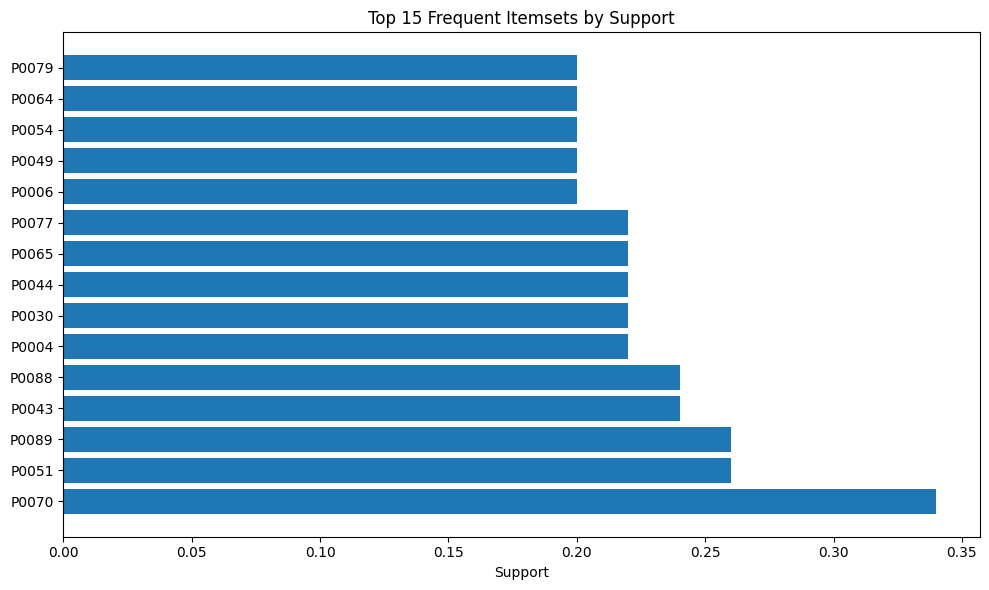

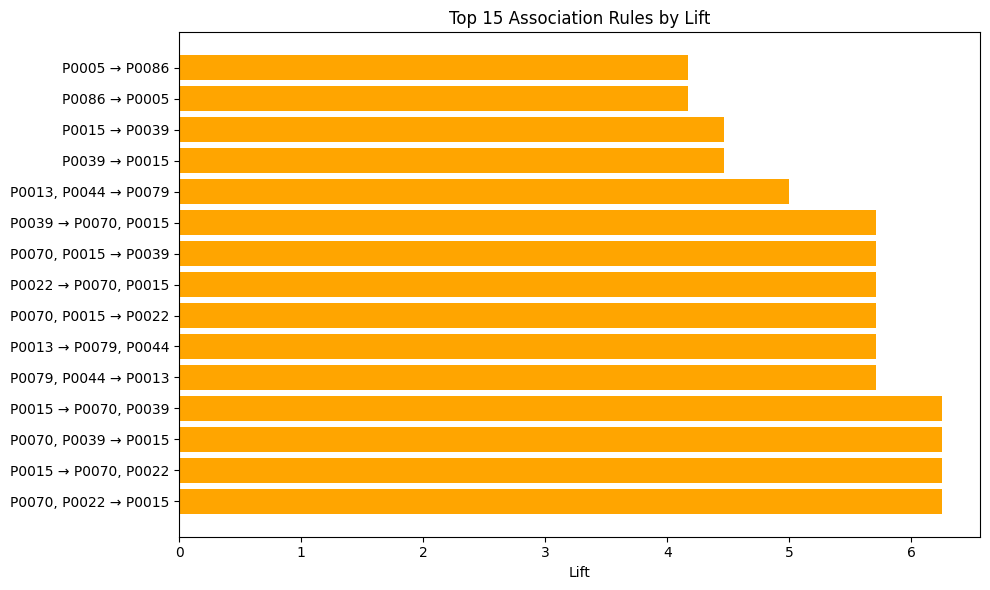

In [ ]:
# Top 15 frequent itemsets by support
top_itemsets = frequent_itemsets.nlargest(15, 'support')
top_itemsets['items'] = top_itemsets['itemsets'].apply(lambda x: ', '.join(list(x)))

plt.figure(figsize=(10, 6))
plt.barh(top_itemsets['items'], top_itemsets['support'])
plt.xlabel('Support')
plt.title('Top 15 Frequent Itemsets by Support')
plt.tight_layout()
plt.show()


top_rules = rules.nlargest(15, 'lift')
top_rules['rule'] = top_rules.apply(lambda x: ', '.join(list(x['antecedents'])) + ' → ' + ', '.join(list(x['consequents'])), axis=1)

plt.figure(figsize=(10, 6))
plt.barh(top_rules['rule'], top_rules['lift'], color='orange')
plt.xlabel('Lift')
plt.title('Top 15 Association Rules by Lift')
plt.tight_layout()
plt.show()

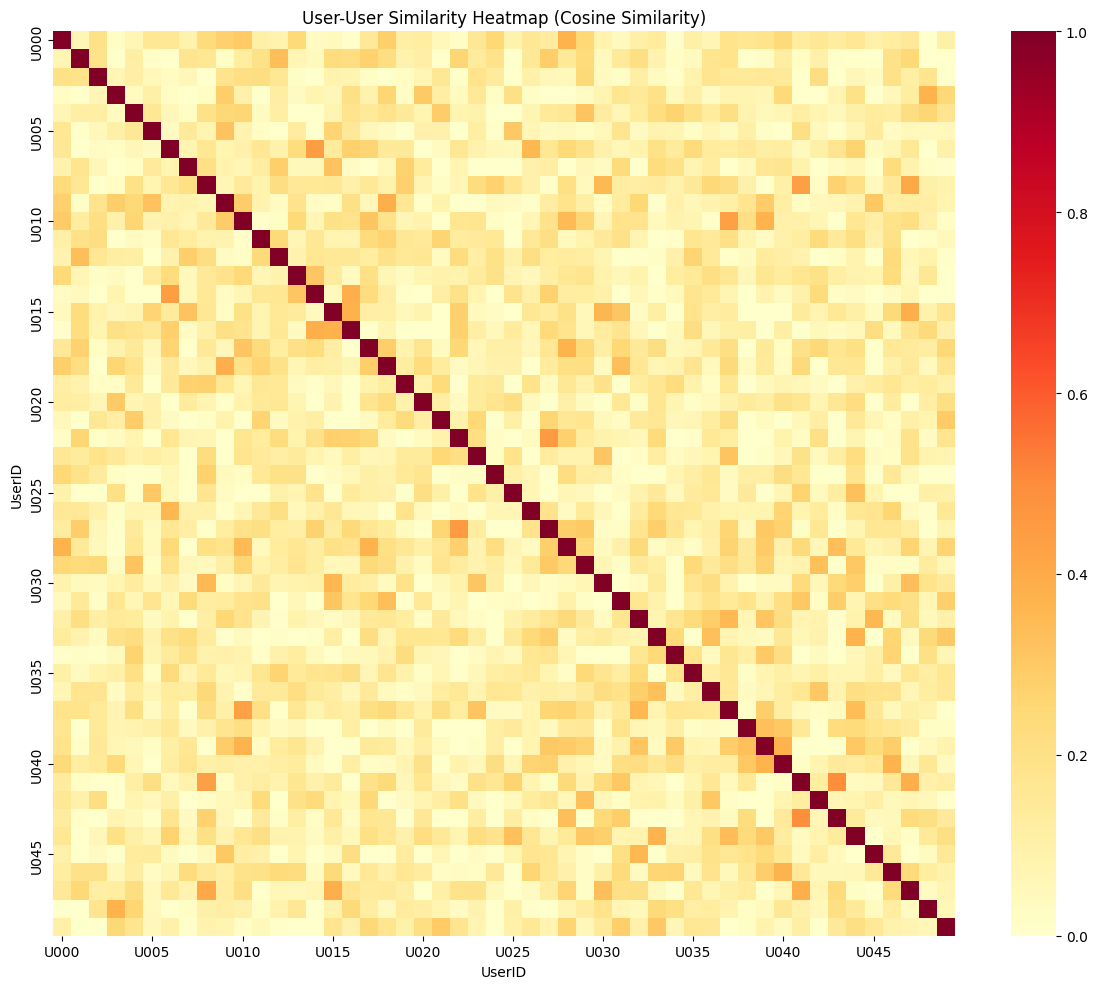

In [ ]:
# part 4

plt.figure(figsize=(12, 10))
sns.heatmap(user_similarity_df, cmap='YlOrRd', xticklabels=5, yticklabels=5)
plt.title('User-User Similarity Heatmap (Cosine Similarity)')
plt.tight_layout()
plt.show()
# Heatmap shows cosine similarity between all user pairs.
# Dark diagonal means each user is 100% similar to themselves (expected).
# Mostly light colors means most users are not very similar to each other,
# consistent with the high sparsity (85%) that users simply haven't rated enough of the same products to show strong similarity.

In [41]:
# Generate top 5 recommendations for all users
all_recs = {}
for user_id in user_item_matrix_filled.index:
    recs = get_recommendations(user_id)
    all_recs[user_id] = list(recs.index)

recs_df = pd.DataFrame.from_dict(all_recs, orient='index', columns=['Rec1', 'Rec2', 'Rec3', 'Rec4', 'Rec5'])
recs_df.head(10)

,Rec1,Rec2,Rec3,Rec4,Rec5
U000,P0032,P0030,P0029,P0083,P0062
U001,P0060,P0061,P0063,P0046,P0071
U002,P0033,P0041,P0032,P0009,P0048
U003,P0021,P0025,P0017,P0030,P0083
U004,P0024,P0041,P0036,P0062,P0078
U005,P0023,P0030,P0017,P0093,P0075
U006,P0075,P0095,P0041,P0037,P0035
U007,P0024,P0017,P0050,P0061,P0046
U008,P0043,P0069,P0080,P0073,P0066
U009,P0008,P0072,P0062,P0052,P0041


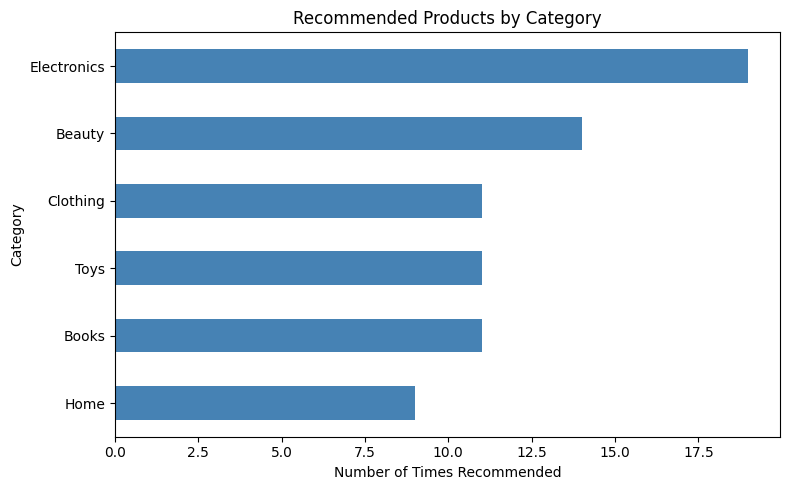

In [ ]:
recs_df.to_csv('recommendations.csv')

all_rec_products = recs_df.values.flatten()
rec_categories = product_details[product_details['ProductID'].isin(all_rec_products)].groupby('Category').size()

plt.figure(figsize=(8, 5))
rec_categories.sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('Number of Times Recommended')
plt.title('Recommended Products by Category')
plt.tight_layout()
plt.show()
# Electronics gets recommended most often, which aligns with it being the most popular category in the original data.
# this might suggest a popularity bias that the system tends to recommend items from categories that already have more dataw which is normal given the data.

In [ ]:

# Q1: How does the sparsity of the data affect your recommender system's performance?
#
# Our user-item matrix has 85.52% sparsity which is only ~15 out of 100 products are rated per user.
# This directly hurts collaborative filtering because cosine similarity depends on overlapping
# ratings between users. With so few shared ratings, the system struggles to identify truly
# similar users, leading to weak predictions. Our evaluation confirmed this: Precision@5 was
# only 0.024 and Recall@5 was 0.085. Sparsity also affects association rule mining  we had
# to lower min_support to 0.08 because with only 50 users, most product combos don't appear
# frequently enough to meet higher thresholds.

# Q2: What kinds of product bundles were discovered in the association rules?
# The strongest bundle found was {P0015, P0070, P0022, P0039}, which appeared repeatedly
# in the top association rules with lift values around 6.0–6.25. This means users who buy
# any subset of these products are 6x more likely to buy the others compared to random chance.
# The confidence of 1.0 on several rules (e.g., {P0070, P0039} → {P0015}) means every single
# user who bought that pair also bought P0015.

# Q3: What improvements would you recommend for a real e-commerce system?
# 1. Hybrid approach: combine collaborative filtering  with content-based
#    filtering  to handle sparsity. When user overlap is low, product features can fill the gap.
# 2. Matrix factorization (SVD/ALS): instead of raw cosine similarity, decompose the
#
#    user-item matrix into latent factors. This handles sparsity better and scales to  millions of users/products.
# 3.  implicit feedback can be used with explicit ratings. Real users don't always rate products. Using clicks, views, cart
#    additions, and purchase history as signals would give far more data than ratings alone.
#
# 4. Cold-start handling: new users and new products have no ratings. Content-based methods,
#    demographic-based recommendations, or asking users to rate a few items on signup would help.